In [9]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# =========================================================
# 1. PATH SETUP
# =========================================================
PLACEKEY_FLOW_FILE = "../data/intermediate/park_flows_placekey.csv"
PROPERTY_FLOW_FILE = "../data/output/park_flows_property_10km.csv"
AUDIT_FILE         = "../data/output/parks_audit.csv"
ACS_FILE           = "../data/output/census_tracts_acs_2022.csv"

# Census sentinel value for missing/suppressed ACS estimates
ACS_MISSING = -666666666

In [10]:
# =========================================================
# 2. LOAD DATA
# =========================================================
print("Loading data...")
pk_flows   = pd.read_csv(PLACEKEY_FLOW_FILE)
prop_flows = pd.read_csv(PROPERTY_FLOW_FILE)
audit      = pd.read_csv(AUDIT_FILE)
acs        = pd.read_csv(ACS_FILE)

print(f"Placekey flows : {len(pk_flows):,} rows  | cols: {list(pk_flows.columns)}")
print(f"Property flows : {len(prop_flows):,} rows  | cols: {list(prop_flows.columns)}")
print(f"Audit          : {len(audit):,} rows  | cols: {list(audit.columns)}")
print(f"ACS tracts     : {len(acs):,} rows  | cols: {list(acs.columns)}")

Loading data...
Placekey flows : 216,367 rows  | cols: ['tract_i', 'park_j', 'distance_km', 'visits']
Property flows : 100,851 rows  | cols: ['tract_i', 'gis_prop_num', 'property_name', 'visits', 'distance_km', 'all_placekeys']
Audit          : 2,851 rows  | cols: ['placekey', 'parent_placekey', 'name', 'gis_prop_num', 'property_name', 'visits', 'acres', 'forever_wild_id']
ACS tracts     : 2,327 rows  | cols: ['geoid', 'tract_name', 'state', 'county', 'tract', 'total_population', 'median_household_income', 'white_pct', 'black_pct', 'aian_pct', 'asian_pct', 'nhpi_pct', 'other_race_pct', 'two_or_more_races_pct', 'under_15_pct', 'over_65_pct']


In [11]:
# =========================================================
# 3. CLEAN ACS & BUILD STANDARD 11-DIGIT GEOID
#
# Reconstruct from state / county / tract integer columns
# into Census 11-digit FIPS: state(2) + county(3) + tract(6)
# e.g. '36005000100'
# =========================================================
acs['geoid_full'] = (
    acs['state'].astype(str).str.zfill(2) +
    acs['county'].astype(str).str.zfill(3) +
    acs['tract'].astype(str).str.zfill(6)
)

# Null out Census sentinel values for suppressed/missing estimates
acs_numeric_cols = [
    'total_population', 'median_household_income',
    'white_pct', 'black_pct', 'aian_pct', 'asian_pct',
    'nhpi_pct', 'other_race_pct', 'two_or_more_races_pct',
    'under_15_pct', 'over_65_pct'
]
for col in acs_numeric_cols:
    if col in acs.columns:
        acs[col] = acs[col].replace(ACS_MISSING, np.nan)

print(f"ACS tracts with suppressed median income: {acs['median_household_income'].isna().sum():,}")
print(f"geoid_full sample: {acs['geoid_full'].head(5).tolist()}")

# Columns to bring into flow dataframes
acs_merge_cols = [
    'geoid_full', 'total_population', 'median_household_income',
    'white_pct', 'black_pct', 'aian_pct', 'asian_pct',
    'other_race_pct', 'two_or_more_races_pct',
    'under_15_pct', 'over_65_pct'
]

ACS tracts with suppressed median income: 126
geoid_full sample: ['36005000100', '36005000200', '36005000400', '36005001600', '36005001901']


In [12]:
# =========================================================
# 4. BUILD PLACEKEY-LEVEL MODEL DATAFRAME
#
# Merges:
#   (a) park attributes  → join on park_j == placekey    (park side)
#   (b) ACS demographics → join on tract_i == geoid_full (home-tract side)
#   distance_km is already present in pk_flows
#
# Interaction terms are handled in the model formula using
# the var1:var2 syntax, so only raw columns are needed here.
# =========================================================

# --- (a) Park-side attributes ---
park_attrs_pk = (
    audit[['placekey', 'gis_prop_num', 'acres', 'forever_wild_id']]
    .drop_duplicates(subset=['placekey', 'gis_prop_num'])
    .groupby('placekey', as_index=False)
    .agg(
        acres           = ('acres', 'sum'),
        forever_wild_id = ('forever_wild_id', 'first')
    )
)

df_pk = pk_flows.merge(park_attrs_pk, left_on='park_j', right_on='placekey', how='left')
print(f"Placekey rows unmatched to audit (acres NaN): {df_pk['acres'].isna().sum():,}")

# --- (b) Home-tract demographics ---
df_pk['tract_i'] = df_pk['tract_i'].astype(str).str.strip()
df_pk = df_pk.merge(acs[acs_merge_cols], left_on='tract_i', right_on='geoid_full', how='left')
print(f"Placekey rows unmatched to ACS (income NaN): {df_pk['median_household_income'].isna().sum():,}")

# --- Feature engineering ---
df_pk['log_dist']         = np.log(df_pk['distance_km'].clip(lower=1e-3))
df_pk['log_area']         = np.log(df_pk['acres'].clip(lower=1e-6))
df_pk['log_pop']          = np.log(df_pk['total_population'].clip(lower=1))
df_pk['is_nature']        = df_pk['forever_wild_id'].notna().astype(int)
df_pk['median_income']    = df_pk['median_household_income']

# Rename pct columns to clean names for readability in model output
df_pk['white']            = df_pk['white_pct']
df_pk['black']            = df_pk['black_pct']
df_pk['asian']            = df_pk['asian_pct']
df_pk['aian']             = df_pk['aian_pct']
df_pk['other_race']       = df_pk['other_race_pct']
df_pk['two_or_more']      = df_pk['two_or_more_races_pct']
df_pk['under_15']         = df_pk['under_15_pct']
df_pk['over_65']          = df_pk['over_65_pct']

model_cols = [
    'visits', 'is_nature', 'log_dist', 'log_area', 'log_pop',
    'median_income', 'white', 'black', 'asian', 'aian',
    'other_race', 'two_or_more', 'under_15', 'over_65',
    'tract_i'
]

df_pk_model = df_pk.dropna(subset=model_cols).copy()
df_pk_model = df_pk_model[df_pk_model['visits'] > 0]

print(f"\nPlacekey model rows (visits > 0, no NaN): {len(df_pk_model):,}")
display(df_pk_model[model_cols[:-1]].describe())

Placekey rows unmatched to audit (acres NaN): 0
Placekey rows unmatched to ACS (income NaN): 3,890

Placekey model rows (visits > 0, no NaN): 212,477


,visits,is_nature,log_dist,log_area,log_pop,median_income,white,black,asian,aian,other_race,two_or_more,under_15,over_65
count,212477.000000,212477.000000,212477.000000,212477.000000,212477.000000,212477.000000,212477.000000,212477.000000,212477.000000,212477.000000,212477.000000,212477.000000,212477.000000,212477.000000
mean,18.360063,0.188703,1.956721,1.836770,8.255154,88284.925328,0.404474,0.184746,0.173274,0.005976,0.142585,0.087983,0.164267,0.162412
std,51.582711,0.391273,1.118789,2.656135,0.540747,43945.881802,0.266276,0.240293,0.172547,0.013487,0.142822,0.058376,0.063004,0.075361
min,4.000000,0.000000,-5.115996,-6.907755,4.488636,12110.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,0.000000,1.301825,-0.036664,7.938802,59138.000000,0.161101,0.017656,0.040749,0.000000,0.031299,0.046147,0.123693,0.113846
50%,8.000000,0.000000,2.062550,1.335001,8.302514,80633.000000,0.380433,0.063240,0.119059,0.000000,0.088971,0.077278,0.163286,0.149975
75%,14.000000,0.000000,2.629945,3.651593,8.622274,106923.000000,0.645286,0.278600,0.254158,0.005495,0.214587,0.120206,0.201984,0.200595
max,1868.000000,1.000000,6.255207,7.927233,9.676901,250001.000000,0.996829,0.974277,0.915435,0.174408,0.789067,0.487997,0.566812,0.910345


In [13]:
# =========================================================
# 5. BUILD PROPERTY-LEVEL MODEL DATAFRAME
# =========================================================

# --- (a) Park-side attributes ---
prop_attrs = (
    audit[['gis_prop_num', 'acres', 'forever_wild_id']]
    .drop_duplicates(subset='gis_prop_num')
)

df_prop = prop_flows.merge(prop_attrs, on='gis_prop_num', how='left')
print(f"Property rows unmatched to audit (acres NaN): {df_prop['acres'].isna().sum():,}")

# --- (b) Home-tract demographics ---
df_prop['tract_i'] = df_prop['tract_i'].astype(str).str.strip()
df_prop = df_prop.merge(acs[acs_merge_cols], left_on='tract_i', right_on='geoid_full', how='left')
print(f"Property rows unmatched to ACS (income NaN): {df_prop['median_household_income'].isna().sum():,}")

# --- Feature engineering ---
df_prop['log_dist']       = np.log(df_prop['distance_km'].clip(lower=1e-3))
df_prop['log_area']       = np.log(df_prop['acres'].clip(lower=1e-6))
df_prop['log_pop']        = np.log(df_prop['total_population'].clip(lower=1))
df_prop['is_nature']      = df_prop['forever_wild_id'].notna().astype(int)
df_prop['median_income']  = df_prop['median_household_income']

df_prop['white']          = df_prop['white_pct']
df_prop['black']          = df_prop['black_pct']
df_prop['asian']          = df_prop['asian_pct']
df_prop['aian']           = df_prop['aian_pct']
df_prop['other_race']     = df_prop['other_race_pct']
df_prop['two_or_more']    = df_prop['two_or_more_races_pct']
df_prop['under_15']       = df_prop['under_15_pct']
df_prop['over_65']        = df_prop['over_65_pct']

model_cols_prop = [
    'visits', 'is_nature', 'log_dist', 'log_area', 'log_pop',
    'median_income', 'white', 'black', 'asian', 'aian',
    'other_race', 'two_or_more', 'under_15', 'over_65',
    'tract_i'
]

df_prop_model = df_prop.dropna(subset=model_cols_prop).copy()
df_prop_model = df_prop_model[df_prop_model['visits'] > 0]

print(f"\nProperty model rows (visits > 0, no NaN): {len(df_prop_model):,}")
display(df_prop_model[model_cols_prop[:-1]].describe())

Property rows unmatched to audit (acres NaN): 0
Property rows unmatched to ACS (income NaN): 1,449

Property model rows (visits > 0, no NaN): 99,402


,visits,is_nature,log_dist,log_area,log_pop,median_income,white,black,asian,aian,other_race,two_or_more,under_15,over_65
count,99402.000000,99402.000000,99402.000000,99402.000000,99402.000000,99402.000000,99402.000000,99402.000000,99402.000000,99402.000000,99402.000000,99402.000000,99402.000000,99402.000000
mean,20.488290,0.080441,1.313475,1.094431,8.245499,86614.902356,0.387212,0.209052,0.154654,0.006349,0.150504,0.091188,0.164563,0.155304
std,42.494084,0.271976,0.797913,2.156072,0.548274,45719.961210,0.262431,0.251720,0.165259,0.013914,0.146736,0.059370,0.065741,0.073358
min,4.000000,0.000000,-5.809143,-6.907755,4.488636,12110.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,0.000000,0.871712,-0.270497,7.927685,56111.000000,0.149796,0.021331,0.034174,0.000000,0.034790,0.048831,0.122099,0.108396
50%,8.000000,0.000000,1.495149,0.765468,8.300280,78088.000000,0.350236,0.080018,0.097855,0.000000,0.099277,0.080586,0.162835,0.142358
75%,20.000000,0.000000,1.942189,2.356600,8.608860,104191.000000,0.622978,0.349407,0.221896,0.006523,0.226568,0.122238,0.202918,0.194074
max,1868.000000,1.000000,2.836619,7.927233,9.676901,250001.000000,0.996829,0.974277,0.915435,0.174408,0.789067,0.487997,0.566812,0.910345


In [14]:
# =========================================================
# 6. PPML — PLACEKEY LEVEL
# =========================================================
formula_pk = """
visits ~ is_nature + log_dist + log_area + log_pop
       + is_nature * median_income
       + is_nature * white
       + is_nature * black
       + is_nature * asian
       + is_nature * aian
       + is_nature * other_race
       + is_nature * two_or_more
       + is_nature * under_15
       + is_nature * over_65
"""

print("Fitting placekey-level PPML...")
res_pk = smf.glm(
    formula=formula_pk,
    data=df_pk_model,
    family=sm.families.Poisson()
).fit(maxiter=200)
print(res_pk.summary())

Fitting placekey-level PPML...
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 visits   No. Observations:               212477
Model:                            GLM   Df Residuals:                   212454
Model Family:                 Poisson   Df Model:                           22
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -3.0479e+06
Date:                Fri, 10 Apr 2026   Deviance:                   5.2416e+06
Time:                        11:19:55   Pearson chi2:                 1.12e+07
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [15]:
# =========================================================
# 7. PPML — PROPERTY LEVEL
# =========================================================
formula_prop = """
visits ~ is_nature + log_dist + log_area + log_pop
       + is_nature * median_income
       + is_nature * white
       + is_nature * black
       + is_nature * asian
       + is_nature * aian
       + is_nature * other_race
       + is_nature * two_or_more
       + is_nature * under_15
       + is_nature * over_65
"""

print("Fitting property-level PPML...")
res_prop = smf.glm(
    formula=formula_prop,
    data=df_prop_model,
    family=sm.families.Poisson()
).fit(maxiter=200)
print(res_prop.summary())

Fitting property-level PPML...
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 visits   No. Observations:                99402
Model:                            GLM   Df Residuals:                    99379
Model Family:                 Poisson   Df Model:                           22
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4181e+06
Date:                Fri, 10 Apr 2026   Deviance:                   2.4187e+06
Time:                        11:19:56   Pearson chi2:                 4.58e+06
No. Iterations:                     6   Pseudo R-squ. (CS):             0.9999
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

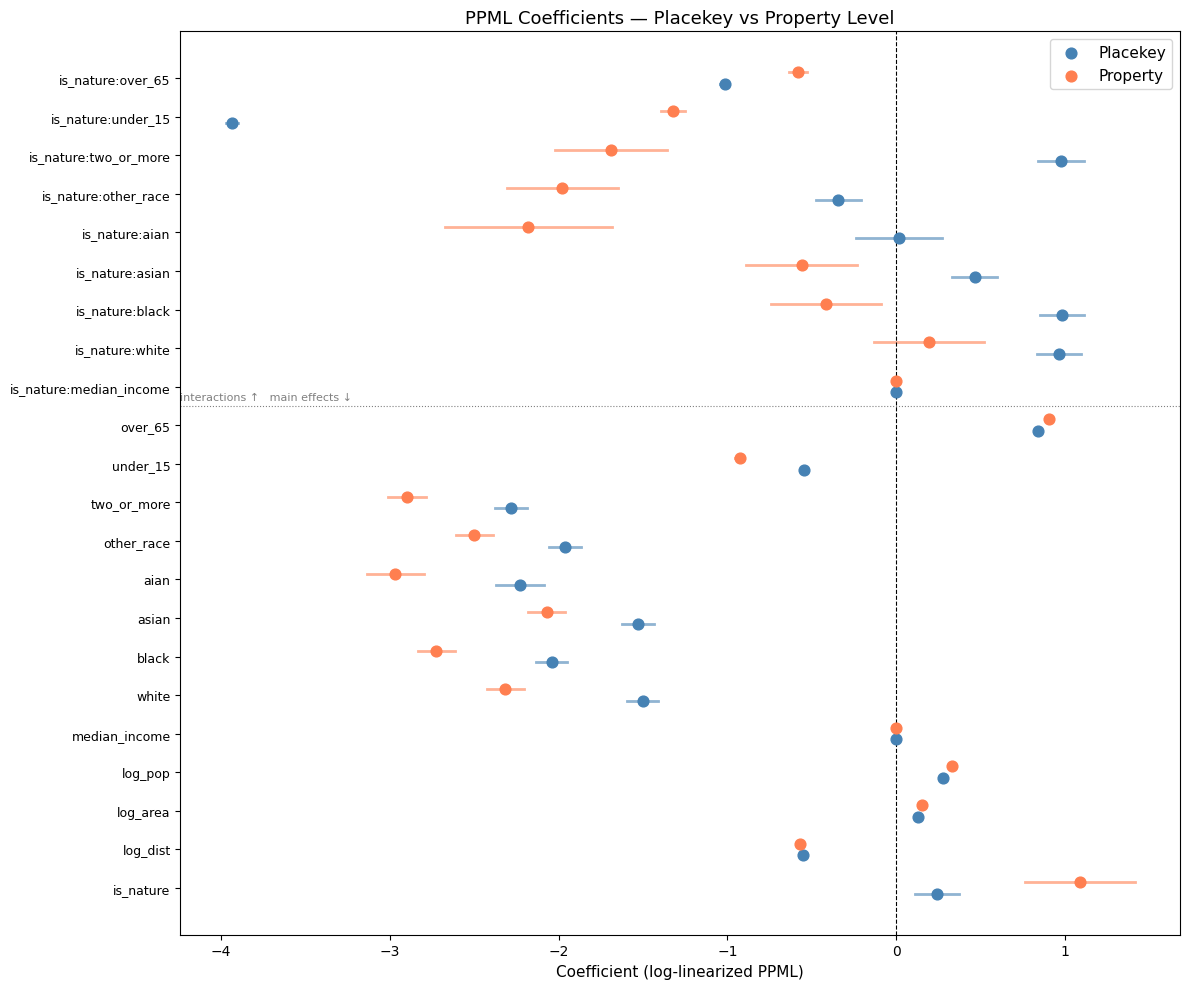

               variable          coef         ci_lo         ci_hi    model
              is_nature  2.403901e-01  1.087129e-01  3.720674e-01 Placekey
               log_dist -5.527606e-01 -5.535729e-01 -5.519483e-01 Placekey
               log_area  1.257657e-01  1.251767e-01  1.263547e-01 Placekey
                log_pop  2.756429e-01  2.737521e-01  2.775336e-01 Placekey
          median_income -7.484434e-07 -7.824936e-07 -7.143933e-07 Placekey
                  white -1.501039e+00 -1.593433e+00 -1.408645e+00 Placekey
                  black -2.040423e+00 -2.132873e+00 -1.947974e+00 Placekey
                  asian -1.529080e+00 -1.621441e+00 -1.436718e+00 Placekey
                   aian -2.230044e+00 -2.371792e+00 -2.088297e+00 Placekey
             other_race -1.962073e+00 -2.054887e+00 -1.869259e+00 Placekey
            two_or_more -2.280215e+00 -2.374434e+00 -2.185996e+00 Placekey
               under_15 -5.475060e-01 -5.683470e-01 -5.266651e-01 Placekey
                over_65  

In [16]:
# =========================================================
# 8. COEFFICIENT COMPARISON
# =========================================================
demo_vars = [
    'median_income', 'white', 'black', 'asian',
    'aian', 'other_race', 'two_or_more', 'under_15', 'over_65'
]

keep_vars = (
    ['is_nature', 'log_dist', 'log_area', 'log_pop'] +
    demo_vars +
    [f'is_nature:{v}' for v in demo_vars]
)

def extract_coefs(res, label):
    available = [v for v in keep_vars if v in res.params.index]
    coefs = res.params[available]
    cis   = res.conf_int().loc[available]
    return pd.DataFrame({
        'variable': available,
        'coef':     coefs.values,
        'ci_lo':    cis[0].values,
        'ci_hi':    cis[1].values,
        'model':    label
    })

coef_pk   = extract_coefs(res_pk,   'Placekey')
coef_prop = extract_coefs(res_prop, 'Property')
coef_df   = pd.concat([coef_pk, coef_prop], ignore_index=True)

# --- Plot ---
plot_vars = coef_pk['variable'].tolist()
fig, ax = plt.subplots(figsize=(12, 10))
colors  = {'Placekey': 'steelblue', 'Property': 'coral'}
offsets = {'Placekey': -0.15, 'Property': 0.15}

for model, grp in coef_df.groupby('model'):
    grp = grp.set_index('variable').reindex(plot_vars).reset_index()
    y = np.arange(len(plot_vars)) + offsets[model]
    ax.scatter(grp['coef'], y, color=colors[model], zorder=3, label=model, s=60)
    for i, (_, row) in enumerate(grp.iterrows()):
        if pd.notna(row['ci_lo']):
            ax.plot([row['ci_lo'], row['ci_hi']], [y[i], y[i]],
                    color=colors[model], alpha=0.6, linewidth=2)

# Divider between main effects and interactions
n_main = len(demo_vars) + 4   # is_nature + log_dist + log_area + log_pop + demos
ax.axhline(n_main - 0.5, color='gray', linewidth=0.8, linestyle=':')
ax.text(ax.get_xlim()[0] if ax.get_xlim()[0] != 0 else -1,
        n_main - 0.35, 'interactions ↑   main effects ↓',
        fontsize=8, color='gray')

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(np.arange(len(plot_vars)))
ax.set_yticklabels(plot_vars, fontsize=9)
ax.set_xlabel('Coefficient (log-linearized PPML)', fontsize=11)
ax.set_title('PPML Coefficients — Placekey vs Property Level', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))